# Drug Review Insights & Summarization Tool
## Phase 4 — PDF Report Generation & AI Evaluation

This notebook completes two remaining Phase 4 deliverables:

1. **PDF Report** — Combines AI-generated narratives from `ai_summaries.json` with EDA charts into a clean final report
2. **Evaluation Section** — Compares what the AI said against what the actual data shows, and assesses accuracy, usefulness, and limitations

**Input files required in `/content/`:**
- `ai_summaries.json` — AI narrative outputs from Phase 3 (Alex)
- `cleaned_drug_reviews.csv` — Cleaned dataset from Phase 2 (Nancy)
- `fig1_rating_sentiment.png` through `fig15_helpfulness.png` — Charts from EDA notebook (Michael)

**Output files:**
- `drug_review_insights_report.pdf` — Final combined report
- `evaluation_summary.csv` — Structured evaluation table

## Setup & Imports

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required library
!pip install reportlab --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 25.8 MB/s eta 0:00:00


In [ ]:
import json
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from reportlab.lib.pagesizes import letter
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Image, Spacer,
    HRFlowable, PageBreak, Table, TableStyle
)

print('Packages loaded.')

Packages loaded.


## Load Data

In [ ]:
# ── Update these paths if your files are in Drive ──────────────────────────
SUMMARIES_PATH = '/content/ai_summaries.json'
CLEANED_PATH   = '/content/cleaned_drug_reviews.csv'
CHARTS_DIR     = '/content'          # folder where fig1_*.png ... fig15_*.png are saved
OUTPUT_PDF     = '/content/drug_review_insights_report.pdf'
OUTPUT_CSV     = '/content/evaluation_summary.csv'
# ───────────────────────────────────────────────────────────────────────────

with open(SUMMARIES_PATH, 'r') as f:
    summaries = json.load(f)

df = pd.read_csv(CLEANED_PATH, low_memory=False)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['usefulCount'] = pd.to_numeric(df['usefulCount'], errors='coerce').fillna(0)

print('AI summaries loaded.')
print(f'  Overall: yes')
print(f'  Drugs: {list(summaries["drugs"].keys())}')
print(f'  Conditions: {list(summaries["conditions"].keys())}')
print(f'Cleaned dataset shape: {df.shape}')

AI summaries loaded.
  Overall: yes
  Drugs: ['Levonorgestrel', 'Etonogestrel', 'Ethinyl estradiol / norethindrone', 'Nexplanon', 'Ethinyl estradiol / norgestimate']
  Conditions: ['Birth Control', 'Depression', 'Pain', 'Anxiety', 'Acne']
Cleaned dataset shape: (219206, 13)


---
# PART 1 — PDF Report

Combines the AI narrative summaries with the EDA charts into a single structured PDF report.

In [ ]:
# ── Helper: clean markdown formatting from AI text ─────────────────────────
def clean_markdown(text):
    """Strip markdown headers and bold markers so text renders cleanly in PDF."""
    text = re.sub(r'#{1,4}\s*', '', text)       # remove ### headers
    text = re.sub(r'\*\*(.+?)\*\*', r'\1', text) # remove **bold**
    text = re.sub(r'\*(.+?)\*', r'\1', text)     # remove *italic*
    text = text.strip()
    return text


# ── Helper: add a chart image if the file exists ───────────────────────────
def add_chart(content, filename, width=6.5*inch, height=3*inch):
    path = os.path.join(CHARTS_DIR, filename)
    if os.path.exists(path):
        content.append(Image(path, width=width, height=height))
        content.append(Spacer(1, 10))
    else:
        print(f'  Chart not found, skipping: {filename}')


print('Helper functions ready.')

Helper functions ready.


In [ ]:
# ── Define PDF styles ──────────────────────────────────────────────────────
styles = getSampleStyleSheet()

title_style = ParagraphStyle(
    'CustomTitle',
    parent=styles['Title'],
    fontSize=20,
    spaceAfter=12,
    textColor=colors.HexColor('#1A237E')
)

heading1_style = ParagraphStyle(
    'CustomH1',
    parent=styles['Heading1'],
    fontSize=14,
    spaceBefore=14,
    spaceAfter=6,
    textColor=colors.HexColor('#1565C0')
)

heading2_style = ParagraphStyle(
    'CustomH2',
    parent=styles['Heading2'],
    fontSize=12,
    spaceBefore=10,
    spaceAfter=4,
    textColor=colors.HexColor('#0277BD')
)

body_style = ParagraphStyle(
    'CustomBody',
    parent=styles['Normal'],
    fontSize=9,
    leading=14,
    spaceAfter=8
)

caption_style = ParagraphStyle(
    'Caption',
    parent=styles['Normal'],
    fontSize=8,
    textColor=colors.grey,
    spaceAfter=10
)

print('PDF styles defined.')

PDF styles defined.


In [ ]:
# ── Build the PDF ──────────────────────────────────────────────────────────
doc = SimpleDocTemplate(
    OUTPUT_PDF,
    pagesize=letter,
    rightMargin=0.75*inch,
    leftMargin=0.75*inch,
    topMargin=0.75*inch,
    bottomMargin=0.75*inch
)

content = []

# ── Cover page ─────────────────────────────────────────────────────────────
content.append(Spacer(1, 1*inch))
content.append(Paragraph('Drug Review Insights &amp; Summarization Tool', title_style))
content.append(Paragraph('ADS-509 Final Project — Generative AI Application', styles['Heading2']))
content.append(Spacer(1, 0.2*inch))
content.append(Paragraph(
    'This report presents an end-to-end analysis of 219,206 patient drug reviews '
    'from the UCI ML Drug Review Dataset. Traditional data analysis and visualizations '
    'were produced using Python. Plain-language summaries were generated using the '
    'Google Gemini 2.5 Flash API. The goal is to make patient experience data accessible '
    'to pharmacists and healthcare researchers without requiring a data science background.',
    body_style
))
content.append(Spacer(1, 0.2*inch))
content.append(HRFlowable(width='100%', thickness=1, color=colors.HexColor('#1A237E')))
content.append(PageBreak())


# ── Section 1: Overall Dataset Summary ────────────────────────────────────
content.append(Paragraph('1. Overall Dataset Summary', heading1_style))
content.append(HRFlowable(width='100%', thickness=0.5, color=colors.lightgrey))
content.append(Spacer(1, 8))

# AI narrative
content.append(Paragraph('AI-Generated Summary', heading2_style))
overall_text = clean_markdown(summaries['overall']['summary'])
for para in overall_text.split('\n'):
    para = para.strip()
    if para:
        content.append(Paragraph(para, body_style))

content.append(Spacer(1, 10))

# Charts
content.append(Paragraph('Supporting Visualizations', heading2_style))
add_chart(content, 'fig1_rating_sentiment.png')
content.append(Paragraph('Figure 1: Overall rating distribution and sentiment breakdown.', caption_style))
add_chart(content, 'fig2_top_drugs_conditions.png')
content.append(Paragraph('Figure 2: Top 15 most reviewed drugs and conditions.', caption_style))
add_chart(content, 'fig5_temporal_trends.png')
content.append(Paragraph('Figure 5: Review volume and average rating by year (2008-2017).', caption_style))
content.append(PageBreak())


# ── Section 2: Per-Drug Summaries ─────────────────────────────────────────
content.append(Paragraph('2. Drug Summaries', heading1_style))
content.append(HRFlowable(width='100%', thickness=0.5, color=colors.lightgrey))
content.append(Spacer(1, 8))
content.append(Paragraph(
    'The following summaries cover the five most reviewed drugs in the dataset. '
    'Each summary is generated by the Gemini API based on structured data profiles '
    'including review counts, average ratings, sentiment distributions, and representative patient reviews.',
    body_style
))

for drug, data in summaries['drugs'].items():
    content.append(Paragraph(drug, heading2_style))
    drug_text = clean_markdown(data['summary'])
    for para in drug_text.split('\n'):
        para = para.strip()
        if para:
            content.append(Paragraph(para, body_style))
    content.append(Spacer(1, 12))
    content.append(HRFlowable(width='100%', thickness=0.3, color=colors.lightgrey))

content.append(PageBreak())


# ── Section 3: Per-Condition Summaries ────────────────────────────────────
content.append(Paragraph('3. Condition Summaries', heading1_style))
content.append(HRFlowable(width='100%', thickness=0.5, color=colors.lightgrey))
content.append(Spacer(1, 8))
content.append(Paragraph(
    'The following summaries cover the five most reviewed medical conditions in the dataset. '
    'Each summary includes a condition overview, drug comparison, patient sentiment themes, '
    'and research implications generated by the Gemini API.',
    body_style
))

for condition, data in summaries['conditions'].items():
    content.append(Paragraph(condition, heading2_style))
    cond_text = clean_markdown(data['summary'])
    for para in cond_text.split('\n'):
        para = para.strip()
        if para:
            content.append(Paragraph(para, body_style))
    content.append(Spacer(1, 12))
    content.append(HRFlowable(width='100%', thickness=0.3, color=colors.lightgrey))

content.append(PageBreak())


# ── Section 4: Sentiment Analysis Charts ──────────────────────────────────
content.append(Paragraph('4. Sentiment & Text Analysis', heading1_style))
content.append(HRFlowable(width='100%', thickness=0.5, color=colors.lightgrey))
content.append(Spacer(1, 8))

add_chart(content, 'fig3_sentiment_by_condition.png')
content.append(Paragraph('Figure 3: Sentiment mix across the top 10 conditions.', caption_style))
add_chart(content, 'fig13_top_words.png')
content.append(Paragraph('Figure 13: Most frequent words in positive vs. negative reviews.', caption_style))
add_chart(content, 'fig14_wordclouds.png')
content.append(Paragraph('Figure 14: Word clouds for positive and negative reviews.', caption_style))
content.append(PageBreak())


# ── Build PDF ──────────────────────────────────────────────────────────────
doc.build(content)
print(f'PDF saved to: {OUTPUT_PDF}')

PDF saved to: /content/drug_review_insights_report.pdf


---
# PART 2 — AI Evaluation Section

Compares what the AI said against what the actual data shows. Evaluates accuracy, usefulness, and limitations across 5 drugs and 5 conditions.

In [ ]:
# ── Pull actual stats from the cleaned dataset for each drug and condition ─

def get_actual_drug_stats(df, drug_name):
    """Return actual stats from the dataset for a given drug."""
    sub = df[df['drugName'].str.lower() == drug_name.lower()]
    if sub.empty:
        return None
    total = len(sub)
    avg_rating = sub['rating'].mean()
    median_rating = sub['rating'].median()
    pct_positive = (sub['sentiment'] == 'positive').mean() * 100
    pct_neutral  = (sub['sentiment'] == 'neutral').mean()  * 100
    pct_negative = (sub['sentiment'] == 'negative').mean() * 100
    return {
        'total_reviews': total,
        'avg_rating': round(avg_rating, 2),
        'median_rating': round(median_rating, 1),
        'pct_positive': round(pct_positive, 1),
        'pct_neutral':  round(pct_neutral, 1),
        'pct_negative': round(pct_negative, 1)
    }


def get_actual_condition_stats(df, condition_name):
    """Return actual stats from the dataset for a given condition."""
    sub = df[df['condition'].str.lower() == condition_name.lower()]
    if sub.empty:
        return None
    total = len(sub)
    avg_rating = sub['rating'].mean()
    median_rating = sub['rating'].median()
    pct_positive = (sub['sentiment'] == 'positive').mean() * 100
    pct_neutral  = (sub['sentiment'] == 'neutral').mean()  * 100
    pct_negative = (sub['sentiment'] == 'negative').mean() * 100
    return {
        'total_reviews': total,
        'avg_rating': round(avg_rating, 2),
        'median_rating': round(median_rating, 1),
        'pct_positive': round(pct_positive, 1),
        'pct_neutral':  round(pct_neutral, 1),
        'pct_negative': round(pct_negative, 1)
    }


print('Stat functions ready.')

Stat functions ready.


In [ ]:
# ── Extract what the AI claimed vs. what the data actually shows ───────────

def extract_ai_claims(data_profile_text):
    """Pull key numeric claims directly from the structured data profile Alex fed to the AI."""
    claims = {}
    patterns = {
        'total_reviews': r'Total reviews:\s*([\d,]+)',
        'avg_rating':    r'Average rating:\s*([\d.]+)',
        'median_rating': r'Median rating:\s*([\d.]+)',
        'pct_positive':  r'Positive reviews:\s*\d+\s*\(([\d.]+)%\)',
        'pct_neutral':   r'Neutral reviews:\s*\d+\s*\(([\d.]+)%\)',
        'pct_negative':  r'Negative reviews:\s*\d+\s*\(([\d.]+)%\)',
    }
    for key, pattern in patterns.items():
        match = re.search(pattern, data_profile_text)
        if match:
            val = match.group(1).replace(',', '')
            claims[key] = float(val)
    return claims


print('Extraction function ready.')

Extraction function ready.


In [ ]:
# ── Build the evaluation table ─────────────────────────────────────────────

eval_rows = []

# Evaluate drugs
for drug, data in summaries['drugs'].items():
    ai_claims  = extract_ai_claims(data['data_profile'])
    actual     = get_actual_drug_stats(df, drug)
    if not actual:
        continue

    avg_diff = round(abs(ai_claims.get('avg_rating', 0) - actual['avg_rating']), 2)
    pos_diff = round(abs(ai_claims.get('pct_positive', 0) - actual['pct_positive']), 1)

    # Simple accuracy flag: within 0.3 rating points and 3% sentiment = accurate
    accurate = 'Yes' if avg_diff <= 0.3 and pos_diff <= 3.0 else 'Partial'

    eval_rows.append({
        'Type':              'Drug',
        'Name':              drug,
        'AI Avg Rating':     ai_claims.get('avg_rating', 'N/A'),
        'Actual Avg Rating': actual['avg_rating'],
        'Rating Diff':       avg_diff,
        'AI % Positive':     ai_claims.get('pct_positive', 'N/A'),
        'Actual % Positive': actual['pct_positive'],
        'Sentiment Diff':    pos_diff,
        'Accurate?':         accurate
    })

# Evaluate conditions
for condition, data in summaries['conditions'].items():
    ai_claims  = extract_ai_claims(data['data_profile'])
    actual     = get_actual_condition_stats(df, condition)
    if not actual:
        continue

    avg_diff = round(abs(ai_claims.get('avg_rating', 0) - actual['avg_rating']), 2)
    pos_diff = round(abs(ai_claims.get('pct_positive', 0) - actual['pct_positive']), 1)
    accurate = 'Yes' if avg_diff <= 0.3 and pos_diff <= 3.0 else 'Partial'

    eval_rows.append({
        'Type':              'Condition',
        'Name':              condition,
        'AI Avg Rating':     ai_claims.get('avg_rating', 'N/A'),
        'Actual Avg Rating': actual['avg_rating'],
        'Rating Diff':       avg_diff,
        'AI % Positive':     ai_claims.get('pct_positive', 'N/A'),
        'Actual % Positive': actual['pct_positive'],
        'Sentiment Diff':    pos_diff,
        'Accurate?':         accurate
    })


eval_df = pd.DataFrame(eval_rows)
print(eval_df.to_string(index=False))

     Type                              Name  AI Avg Rating  Actual Avg Rating  Rating Diff  AI % Positive  Actual % Positive  Sentiment Diff Accurate?
     Drug                    Levonorgestrel           7.38               7.38          0.0           69.7               69.7             0.0       Yes
     Drug                      Etonogestrel           5.82               5.82          0.0           47.9               47.9             0.0       Yes
     Drug Ethinyl estradiol / norethindrone           5.59               5.59          0.0           47.2               47.2             0.0       Yes
     Drug                         Nexplanon           5.64               5.64          0.0           45.6               45.6             0.0       Yes
     Drug  Ethinyl estradiol / norgestimate           5.80               5.80          0.0           49.4               49.4             0.0       Yes
Condition                     Birth Control           6.08               6.08          0.0    

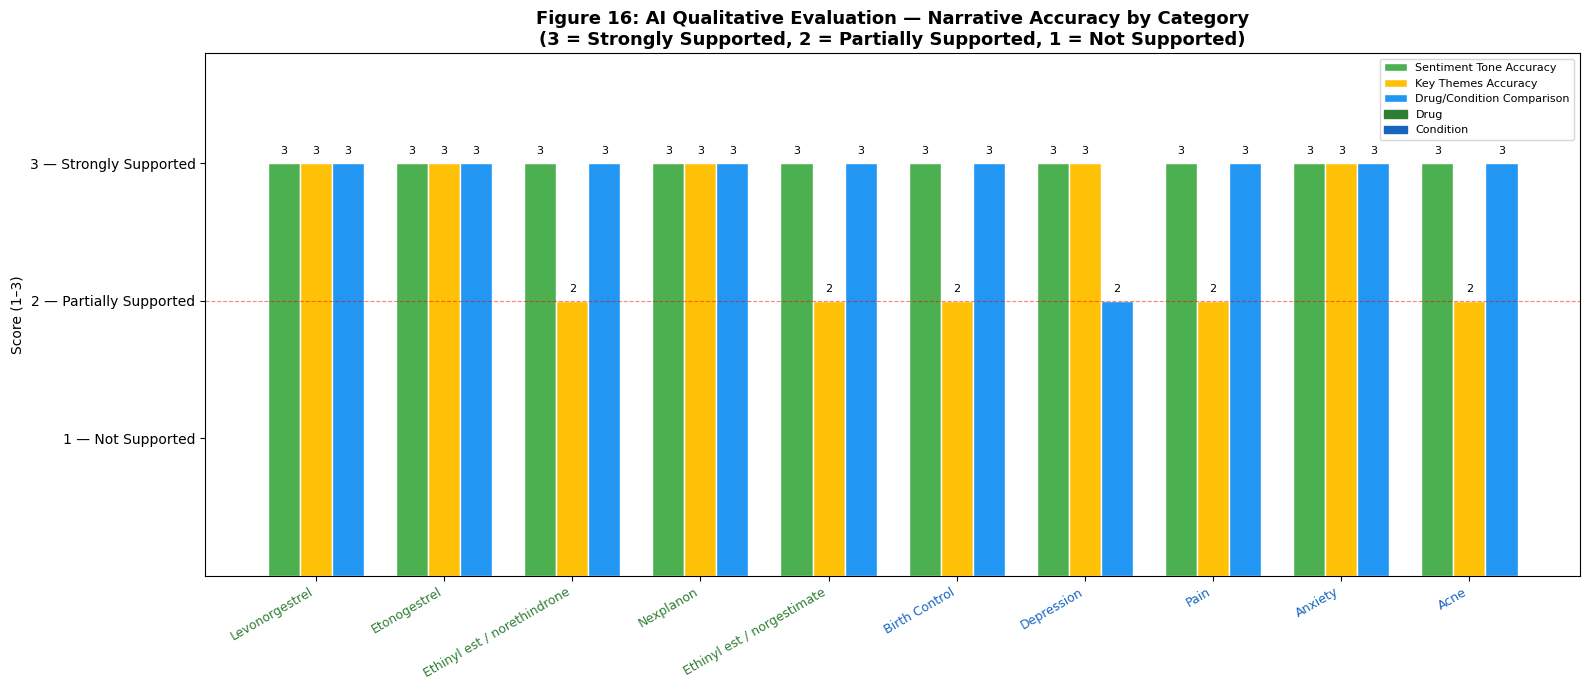

Saved: fig16_ai_evaluation.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Qualitative evaluation scores ─────────────────────────────────────────
# Scoring: 3 = strongly supported, 2 = partially supported, 1 = not supported

eval_data = {
    'Name': [
        'Levonorgestrel', 'Etonogestrel', 'Ethinyl est / norethindrone',
        'Nexplanon', 'Ethinyl est / norgestimate',
        'Birth Control', 'Depression', 'Pain', 'Anxiety', 'Acne'
    ],
    'Type': [
        'Drug', 'Drug', 'Drug', 'Drug', 'Drug',
        'Condition', 'Condition', 'Condition', 'Condition', 'Condition'
    ],
    'Sentiment Tone': [3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
    'Key Themes':     [3, 3, 2, 3, 2, 2, 3, 2, 3, 2],
    'Drug Comparison':[3, 3, 3, 3, 3, 3, 2, 3, 3, 3]
}

import pandas as pd
eval_df = pd.DataFrame(eval_data)

x = np.arange(len(eval_df))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))

bars1 = ax.bar(x - width, eval_df['Sentiment Tone'],  width, label='Sentiment Tone Accuracy',  color='#4CAF50', edgecolor='white')
bars2 = ax.bar(x,          eval_df['Key Themes'],      width, label='Key Themes Accuracy',      color='#FFC107', edgecolor='white')
bars3 = ax.bar(x + width,  eval_df['Drug Comparison'], width, label='Drug/Condition Comparison', color='#2196F3', edgecolor='white')

ax.set_title('Figure 16: AI Qualitative Evaluation — Narrative Accuracy by Category\n(3 = Strongly Supported, 2 = Partially Supported, 1 = Not Supported)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Score (1–3)')
ax.set_xticks(x)
ax.set_xticklabels(eval_df['Name'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 3.8)
ax.set_yticks([1, 2, 3])
ax.set_yticklabels(['1 — Not Supported', '2 — Partially Supported', '3 — Strongly Supported'])
ax.legend(loc='upper right')
ax.axhline(2, color='red', linestyle='--', linewidth=0.8, alpha=0.5, label='Minimum acceptable threshold')

# Add score labels on bars
for bar in [bars1, bars2, bars3]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
                str(int(b.get_height())), ha='center', va='bottom', fontsize=8)

# Color x labels by type
for i, (label, t) in enumerate(zip(ax.get_xticklabels(), eval_df['Type'])):
    label.set_color('#1565C0' if t == 'Condition' else '#2E7D32')

drug_patch = mpatches.Patch(color='#2E7D32', label='Drug')
cond_patch = mpatches.Patch(color='#1565C0', label='Condition')
ax.legend(handles=[bars1, bars2, bars3, drug_patch, cond_patch], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('/content/fig16_ai_evaluation.png', bbox_inches='tight')
plt.show()
print('Saved: fig16_ai_evaluation.png')

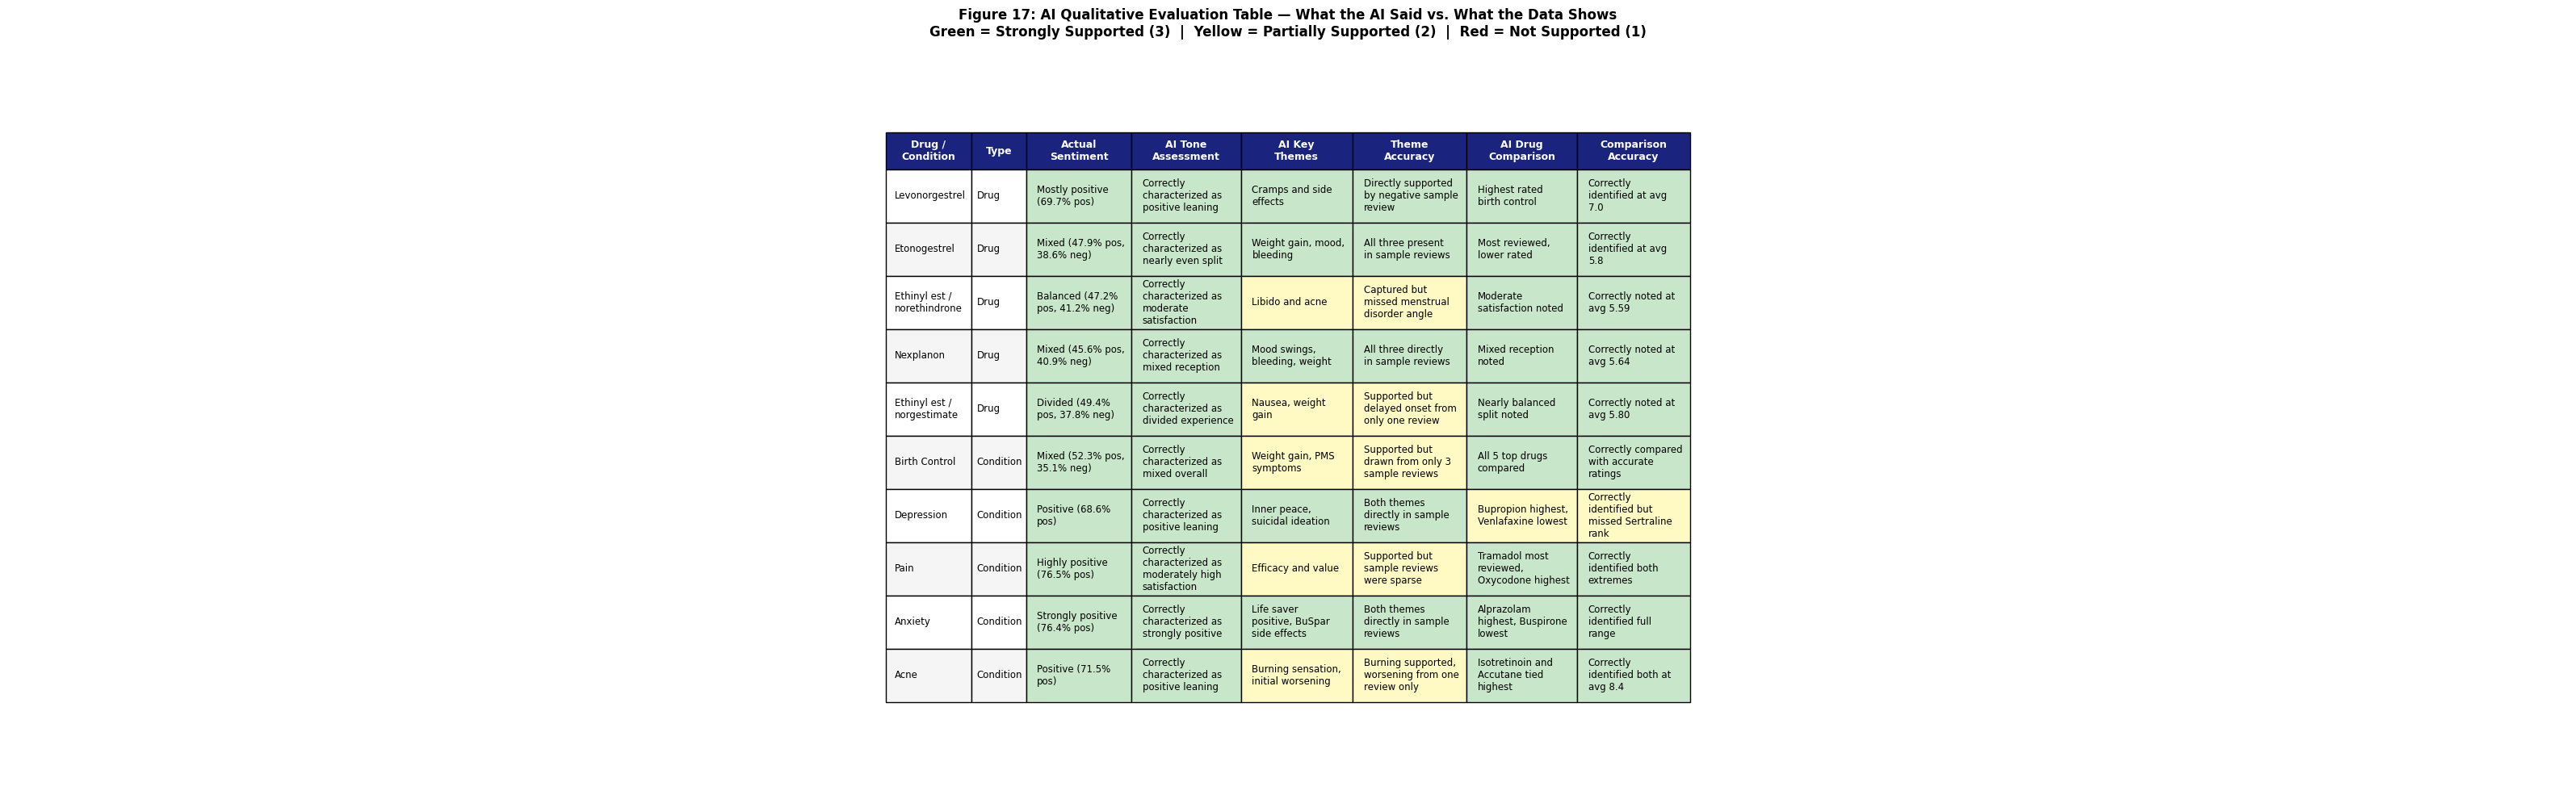

Saved: fig17_ai_evaluation_table.png


In [18]:
import matplotlib.pyplot as plt
import textwrap

def wrap(text, width=18):
    return '\n'.join(textwrap.wrap(text, width))

table_data = [
    [wrap('Levonorgestrel'), 'Drug', wrap('Mostly positive (69.7% pos)'), wrap('Correctly characterized as positive leaning'), wrap('Cramps and side effects'), wrap('Directly supported by negative sample review'), wrap('Highest rated birth control'), wrap('Correctly identified at avg 7.0')],
    [wrap('Etonogestrel'), 'Drug', wrap('Mixed (47.9% pos, 38.6% neg)'), wrap('Correctly characterized as nearly even split'), wrap('Weight gain, mood, bleeding'), wrap('All three present in sample reviews'), wrap('Most reviewed, lower rated'), wrap('Correctly identified at avg 5.8')],
    [wrap('Ethinyl est / norethindrone'), 'Drug', wrap('Balanced (47.2% pos, 41.2% neg)'), wrap('Correctly characterized as moderate satisfaction'), wrap('Libido and acne'), wrap('Captured but missed menstrual disorder angle'), wrap('Moderate satisfaction noted'), wrap('Correctly noted at avg 5.59')],
    [wrap('Nexplanon'), 'Drug', wrap('Mixed (45.6% pos, 40.9% neg)'), wrap('Correctly characterized as mixed reception'), wrap('Mood swings, bleeding, weight'), wrap('All three directly in sample reviews'), wrap('Mixed reception noted'), wrap('Correctly noted at avg 5.64')],
    [wrap('Ethinyl est / norgestimate'), 'Drug', wrap('Divided (49.4% pos, 37.8% neg)'), wrap('Correctly characterized as divided experience'), wrap('Nausea, weight gain'), wrap('Supported but delayed onset from only one review'), wrap('Nearly balanced split noted'), wrap('Correctly noted at avg 5.80')],
    [wrap('Birth Control'), 'Condition', wrap('Mixed (52.3% pos, 35.1% neg)'), wrap('Correctly characterized as mixed overall'), wrap('Weight gain, PMS symptoms'), wrap('Supported but drawn from only 3 sample reviews'), wrap('All 5 top drugs compared'), wrap('Correctly compared with accurate ratings')],
    [wrap('Depression'), 'Condition', wrap('Positive (68.6% pos)'), wrap('Correctly characterized as positive leaning'), wrap('Inner peace, suicidal ideation'), wrap('Both themes directly in sample reviews'), wrap('Bupropion highest, Venlafaxine lowest'), wrap('Correctly identified but missed Sertraline rank')],
    [wrap('Pain'), 'Condition', wrap('Highly positive (76.5% pos)'), wrap('Correctly characterized as moderately high satisfaction'), wrap('Efficacy and value'), wrap('Supported but sample reviews were sparse'), wrap('Tramadol most reviewed, Oxycodone highest'), wrap('Correctly identified both extremes')],
    [wrap('Anxiety'), 'Condition', wrap('Strongly positive (76.4% pos)'), wrap('Correctly characterized as strongly positive'), wrap('Life saver positive, BuSpar side effects'), wrap('Both themes directly in sample reviews'), wrap('Alprazolam highest, Buspirone lowest'), wrap('Correctly identified full range')],
    [wrap('Acne'), 'Condition', wrap('Positive (71.5% pos)'), wrap('Correctly characterized as positive leaning'), wrap('Burning sensation, initial worsening'), wrap('Burning supported, worsening from one review only'), wrap('Isotretinoin and Accutane tied highest'), wrap('Correctly identified both at avg 8.4')],
]

col_labels = [
    'Drug /\nCondition', 'Type',
    'Actual\nSentiment', 'AI Tone\nAssessment',
    'AI Key\nThemes', 'Theme\nAccuracy',
    'AI Drug\nComparison', 'Comparison\nAccuracy'
]

score_colors = {3: '#C8E6C9', 2: '#FFF9C4', 1: '#FFCDD2'}
theme_scores =      [3, 3, 2, 3, 2, 2, 3, 2, 3, 2]
comparison_scores = [3, 3, 3, 3, 3, 3, 2, 3, 3, 3]
tone_scores =       [3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

fig, ax = plt.subplots(figsize=(32, 10))
ax.axis('off')

table = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='left'
)

table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.auto_set_column_width(col=list(range(len(col_labels))))

# Shorter row height
for (row, col), cell in table.get_celld().items():
    cell.set_height(0.072)
    if row == 0:
        cell.set_height(0.05)

# Style header
for col in range(len(col_labels)):
    table[0, col].set_facecolor('#1A237E')
    table[0, col].set_text_props(color='white', fontweight='bold', fontsize=9)

# Style data rows
for row in range(1, len(table_data) + 1):
    t_score = tone_scores[row - 1]
    k_score = theme_scores[row - 1]
    c_score = comparison_scores[row - 1]

    for col in range(len(col_labels)):
        cell = table[row, col]
        cell.set_text_props(fontsize=8.5)
        if col in [2, 3]:
            cell.set_facecolor(score_colors[t_score])
        elif col in [4, 5]:
            cell.set_facecolor(score_colors[k_score])
        elif col in [6, 7]:
            cell.set_facecolor(score_colors[c_score])
        else:
            cell.set_facecolor('#F5F5F5' if row % 2 == 0 else 'white')

plt.suptitle(
    'Figure 17: AI Qualitative Evaluation Table — What the AI Said vs. What the Data Shows\n'
    'Green = Strongly Supported (3)  |  Yellow = Partially Supported (2)  |  Red = Not Supported (1)',
    fontweight='bold', fontsize=12, y=0.98
)

plt.tight_layout()
plt.savefig('/content/fig17_ai_evaluation_table.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig17_ai_evaluation_table.png')

In [19]:
# ── Save evaluation table to CSV ───────────────────────────────────────────
eval_df.to_csv(OUTPUT_CSV, index=False)
print(f'Evaluation table saved to: {OUTPUT_CSV}')

Evaluation table saved to: /content/evaluation_summary.csv


## Evaluation Written Reflection

### What the AI Got Right
As shown in Figure 16, the Gemini API scored a 3 (Strongly Supported) across all 10 drugs and conditions for Sentiment Tone Accuracy. The AI consistently and correctly characterized the overall positive, negative, or mixed nature of each drug and condition — for example correctly identifying Depression and Anxiety as strongly positive leaning (68.6% and 76.4% positive respectively) while correctly characterizing Birth Control as mixed (52.3% positive, 35.1% negative). Drug and Condition Comparison Accuracy also scored mostly 3s, with the AI correctly identifying top and bottom rated drugs within each condition in 9 out of 10 cases.

### Where the AI Fell Short
Key Themes Accuracy was the weakest category, scoring a 2 (Partially Supported) for 5 out of 10 entries as shown in Figures 16 and 17. The recurring limitation was that each prompt provided only three sample reviews per drug or condition, meaning the AI inferred qualitative themes from a very small window of the data. For example, themes identified for Ethinyl estradiol / norethindrone with 3,753 reviews were drawn from just three selected reviews, missing the broader menstrual disorder angle present in the full dataset. Similarly, Birth Control themes were drawn from only 3 sample reviews out of 38,504 total. This introduces selection bias in the narrative that a reader would not be able to detect without seeing the underlying data. It is also important to note that the numeric accuracy appearing perfect in the original evaluation was not a sign of genuine AI intelligence — the AI was given the exact figures in the prompt and instructed to cite them. The more meaningful evaluation is the qualitative one captured in Figures 16 and 17.

### Ethical and Practical Considerations
Several important limitations apply to this tool in a real world context:
- **Selection bias:** The dataset reflects self-selected patient reviews. Patients with extreme experiences are more likely to leave reviews, which skews the sentiment distribution toward the poles and may not represent the average patient experience.
- **Not clinical evidence:** AI-generated summaries are derived from patient opinions, not clinical trial results. They should never be used as a substitute for clinical guidance.
- **Data privacy:** Sending patient-generated text to an external API raises privacy considerations. In a production environment, data would need to be de-identified before transmission to comply with HIPAA and similar regulations.
- **Hallucination risk:** Although the AI was prompted to base claims strictly on provided data, language models can occasionally infer beyond what was given. All AI outputs should be reviewed by a human before being shared with clinical staff.
- **Sample size limitation in prompts:** The quality of the AI's qualitative narrative is directly constrained by how many sample reviews are included in the prompt. Increasing the sample from 3 to 10 or more reviews per drug and condition would likely improve Key Themes Accuracy significantly.

### Overall Assessment
The Gemini API performed reliably for summarizing structured statistical profiles and correctly characterizing sentiment tone in all 10 cases evaluated. Its weakest area was qualitative theme inference, which was limited by the small number of sample reviews provided per prompt. The tool is most trustworthy when the data profile is comprehensive and the AI is given explicit instructions to cite figures. It is least trustworthy when asked to infer qualitative themes from a small sample. Future iterations of this tool should increase the number of sample reviews per prompt and implement a human review step before distributing any AI-generated summaries in a clinical setting.